In [1]:
import pandas as pd 
import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import matplotlib.dates as mdates
def weight_check(weight_df):
    weight_df_sum = np.sum(weight_df[weight_df.columns.values[1:]],axis=1)
    for i in weight_df_sum:
        if round(i,4) > 1:
            return "weight sum >1, ",i

            break
    if (weight_df[weight_df.columns.values[1:]].values < 0).any() == True:
        return "negative value in weight"
    else:
        return True

In [2]:
pool_lst_v2 = [
"FPT","CMG","ELC",#tech
"VGI","DCL",#others
"SSI","VPB","TCB","VCB","VND","TPB","BID","CTG",#fin
"VRE","VIC","VHM","CEO","DXG",#fin
"MWG","VJC","TNG","VGT","TCM","PNJ","MSH",#goods
"HAG","HNG","MSN","DBC","VNM","VHC","ANV",#goods
"GEX","VCG","CII","VSC","HUT","HBC",#industrials
"HPG","GVR","NKG","DPM","HSG",#industrials
"PVD","PVS","BSR",#industrials
"POW"#industrials
]
len(pool_lst_v2)
#remove BAF and KHG because of missing value
#remove HVN due to low ROE

47

In [18]:
weight_delta1 = pd.read_csv('weight/close_delta1w_clipneg.csv',index_col=0).drop(columns='time')
weight_roe = pd.read_csv('weight/roe.csv',index_col=0).drop(columns='time')
weight_excessive_delta1 = pd.read_csv("weight/excessive_delta1.csv",index_col=0).drop(columns='time')

timerange = np.array(pd.read_csv('weight/roe.csv',index_col=0)['time'])

weight_df = (weight_delta1+weight_roe+weight_excessive_delta1)/3
print(weight_check(weight_df))
weight_df['time'] = timerange

weight_df

True


,FPT,CMG,ELC,VGI,DCL,SSI,VPB,TCB,VCB,VND,...,HPG,GVR,NKG,DPM,HSG,PVD,PVS,BSR,POW,time
0,0.010395,0.003789,0.002123,0.004231,0.006095,0.003873,0.011766,0.009176,0.011630,0.005910,...,0.009026,0.003528,0.003348,0.002834,0.006042,0.001140,0.001952,0.000000,0.003727,2020-01-05
1,0.010395,0.003789,0.070192,0.004231,0.006095,0.005087,0.036410,0.009176,0.011630,0.005910,...,0.009506,0.003528,0.151514,0.002834,0.015505,0.001140,0.014609,0.000000,0.003727,2020-01-12
2,0.011255,0.003789,0.002123,0.045049,0.012540,0.053787,0.049786,0.013715,0.066089,0.010803,...,0.039105,0.016470,0.114585,0.002834,0.048506,0.001140,0.001952,0.000000,0.003727,2020-01-19
3,0.010395,0.003789,0.002903,0.063701,0.007123,0.004611,0.054581,0.025771,0.011630,0.029825,...,0.036604,0.036616,0.003348,0.004641,0.039967,0.009604,0.010856,0.086831,0.016480,2020-01-26
4,0.017364,0.010757,0.053833,0.011200,0.307461,0.010842,0.018734,0.016144,0.018598,0.012878,...,0.015995,0.010496,0.010316,0.009803,0.013011,0.008109,0.008921,0.006969,0.010696,2020-02-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,0.018707,0.010026,0.006231,0.016581,0.008663,0.028441,0.033473,0.010956,0.014617,0.022584,...,0.020856,0.013078,0.016980,0.006249,0.010782,0.008256,0.011306,0.050128,0.008541,2025-10-12
302,0.016736,0.009052,0.008262,0.015732,0.003278,0.010327,0.009303,0.026587,0.011039,0.007219,...,0.008490,0.008110,0.003721,0.005977,0.005527,0.004963,0.007624,0.004003,0.005153,2025-10-19
303,0.109917,0.044253,0.029247,0.089715,0.048383,0.012093,0.012349,0.012423,0.014085,0.010265,...,0.011536,0.011156,0.006767,0.009023,0.008573,0.014212,0.032438,0.007049,0.008199,2025-10-26
304,0.039544,0.037952,0.021474,0.057821,0.025895,0.010171,0.010427,0.010501,0.012737,0.008343,...,0.013497,0.041409,0.015868,0.021957,0.016085,0.031523,0.026271,0.005127,0.030502,2025-11-02


In [30]:
weight_df_sum = np.sum(weight_excessive_delta1[weight_excessive_delta1.columns.values[:-1]],axis=1)
weight_df_sum


0      0.000000
1      1.000000
2      1.000000
3      0.983358
4      0.979094
         ...   
301    1.000000
302    0.993907
303    0.984770
304    0.964592
305    0.970262
Length: 306, dtype: float64

In [6]:
# weight_df = pd.read_csv("weight/excessive_delta1.csv",index_col=0)
# weight_df

0      0.0
1      1.0
2      1.0
3      1.0
4      1.0
      ... 
301    1.0
302    1.0
303    1.0
304    1.0
305    1.0
Length: 306, dtype: float64

In [137]:
# tmp_df = pd.read_csv("weight/revenue_sector_neu.csv")
# tmp_df_date = tmp_df['time']
# timerange = np.array(tmp_df_date)
# weight_df = pd.DataFrame(data=timerange)
# for i1 in pool_lst_v2:
#     weight_df[i1] = np.nan
# weight_df = weight_df.fillna(1/len(pool_lst_v2))

In [8]:

pool = list(weight_df.columns.values)
pool.remove('time')


_____________


In [9]:
pool_lst = []
pool = pool
for i0 in pool:
    temp_df = pd.read_csv(f"raw_data/pv/{i0}.csv")
    temp_df = temp_df[['time','close']]
    temp_df.columns = ['time',i0]
    temp_df.set_index("time")
    pool_lst.append(temp_df)
#initialize pool list

In [10]:
tmp_df = pd.read_csv("raw_data/pv/FPT.csv")
tmp_df_date = tmp_df['time']
timerange = np.array(tmp_df_date)
pool_df = pd.DataFrame(data=timerange)
pool_df.columns = ['time']

for i1 in pool_lst:
    pool_df = pool_df.merge(i1, how="outer")
pool_df = pool_df.ffill(axis=0)
pool_df
#initialize pool_df

,time,FPT,CMG,ELC,VGI,DCL,SSI,VPB,TCB,VCB,...,HBC,HPG,GVR,NKG,DPM,HSG,PVD,PVS,BSR,POW
0,2020-01-05,21.03,16.33,3.10,24.75,27.90,6.58,6.66,11.17,38.82,...,9.75,8.33,10.41,3.88,4.35,5.29,11.26,15.22,4.63,11.16
1,2020-01-12,20.99,15.97,3.36,22.87,24.60,6.60,6.87,10.94,38.65,...,10.01,8.34,9.96,4.58,4.33,5.36,11.22,15.48,4.40,10.59
2,2020-01-19,21.03,15.74,3.28,23.86,24.90,6.94,7.15,11.05,40.80,...,9.80,8.62,10.14,5.07,4.25,5.60,10.85,15.06,4.18,10.30
3,2020-01-26,20.63,15.69,3.29,26.34,25.00,6.96,7.70,11.43,40.33,...,10.05,9.07,10.76,4.86,4.28,5.95,11.08,15.39,4.80,10.59
4,2020-02-02,18.98,14.60,3.31,24.75,26.00,6.38,7.33,10.20,38.30,...,8.94,8.31,9.61,4.27,3.94,5.40,9.85,13.71,4.35,10.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,2025-10-12,96.10,40.00,21.43,68.70,29.50,40.70,32.10,39.35,64.20,...,7.20,29.60,28.05,17.90,24.45,19.00,21.60,32.80,18.08,14.60
302,2025-10-19,88.10,37.30,20.75,65.30,29.50,40.80,31.95,40.65,61.90,...,6.50,28.00,27.10,17.75,23.15,18.25,20.00,30.40,17.15,14.15
303,2025-10-26,97.70,38.75,21.20,70.90,31.00,36.00,29.20,36.10,59.50,...,6.30,26.40,26.55,15.50,23.00,16.30,20.15,31.20,16.90,13.40
304,2025-11-02,103.90,41.90,21.95,79.40,32.95,34.30,28.70,35.10,59.60,...,6.70,26.70,29.05,16.00,24.00,16.75,21.65,32.80,16.65,14.35


In [11]:
delta_df = pd.DataFrame(data=timerange)
for i2 in pool:
    #delta_df[i2] = pool_df[i2].shift(-1)-pool_df[i2]
    delta_df[i2] = pool_df[i2]-pool_df[i2].shift(1)
delta_df
#delta_df = delta_df.fillna(0)
#delta_df.replace([np.inf, -np.inf,np.nan], 0, inplace=True)
#initialize delta_df

,0,FPT,CMG,ELC,VGI,DCL,SSI,VPB,TCB,VCB,...,HBC,HPG,GVR,NKG,DPM,HSG,PVD,PVS,BSR,POW
0,2020-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-12,-0.04,-0.36,0.26,-1.88,-3.30,0.02,0.21,-0.23,-0.17,...,0.26,0.01,-0.45,0.70,-0.02,0.07,-0.04,0.26,-0.23,-0.57
2,2020-01-19,0.04,-0.23,-0.08,0.99,0.30,0.34,0.28,0.11,2.15,...,-0.21,0.28,0.18,0.49,-0.08,0.24,-0.37,-0.42,-0.22,-0.29
3,2020-01-26,-0.40,-0.05,0.01,2.48,0.10,0.02,0.55,0.38,-0.47,...,0.25,0.45,0.62,-0.21,0.03,0.35,0.23,0.33,0.62,0.29
4,2020-02-02,-1.65,-1.09,0.02,-1.59,1.00,-0.58,-0.37,-1.23,-2.03,...,-1.11,-0.76,-1.15,-0.59,-0.34,-0.55,-1.23,-1.68,-0.45,-0.57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,2025-10-12,2.70,0.85,-0.28,1.40,1.50,3.05,2.60,1.00,2.50,...,-0.10,1.95,1.35,1.20,0.40,0.95,0.80,1.30,1.95,0.55
302,2025-10-19,-8.00,-2.70,-0.68,-3.40,0.00,0.10,-0.15,1.30,-2.30,...,-0.70,-1.60,-0.95,-0.15,-1.30,-0.75,-1.60,-2.40,-0.93,-0.45
303,2025-10-26,9.60,1.45,0.45,5.60,1.50,-4.80,-2.75,-4.55,-2.40,...,-0.20,-1.60,-0.55,-2.25,-0.15,-1.95,0.15,0.80,-0.25,-0.75
304,2025-11-02,6.20,3.15,0.75,8.50,1.95,-1.70,-0.50,-1.00,0.10,...,0.40,0.30,2.50,0.50,1.00,0.45,1.50,1.60,-0.25,0.95


capN = (weightN * ( capN-1 + (closeN - closeN-1)*Volume_boughtN-1) //closeN) * closeN

cap0 = (weight0*cap0 // close0)*close0 

cap1 =  (  weight1*  ( cap0 + chg0*volume0 ) //close1 ) *close1

2317504085.9499993


<Figure size 1920x960 with 0 Axes>

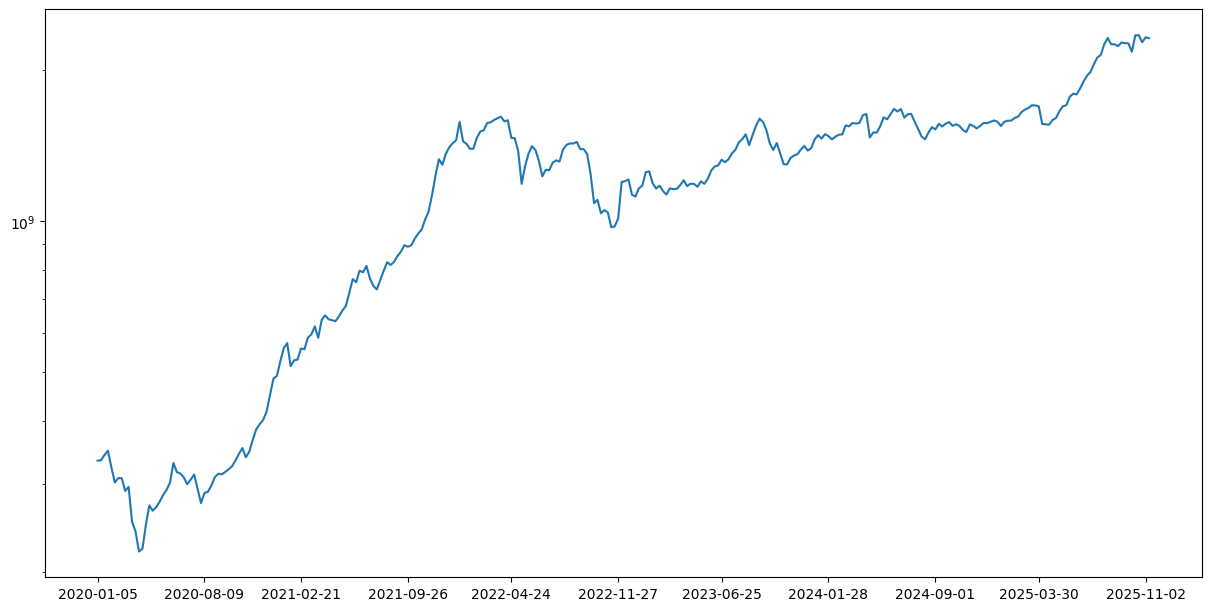

In [14]:
beginning_capital = 1000000000 #1b
# stock_capital_change_lst =[]
# allocation_value_lst = []
# actual_allocation_value_lst = []
# portfolio_capital_change = []
# portfolio_value = []
closechange_lst = []
capital_history = []
cap_change_lst = []
for index, row in pool_df.iterrows():
    if index ==0:
        capital = beginning_capital
        allocation_volume = weight_df[pool].values[index]*capital //pool_df[pool].values[index] 
        cap_allocation = allocation_volume*pool_df[pool].values[index]
        cap_actual = np.nansum(cap_allocation)
        if cap_actual ==0:
            capital = beginning_capital
        else:
            capital = cap_actual
        capital_history.append(float(capital))
    if index >0:
        #print(allocation_volume)
        cap_change = np.sum(delta_df[pool].values[index]*allocation_volume)
        cap_change_lst.append(cap_change)
        new_cap = capital+cap_change
        #capital = new_cap

        allocation_volume = weight_df[pool].values[index]*new_cap //pool_df[pool].values[index] 
        cap_allocation = allocation_volume*pool_df[pool].values[index]
        cap_actual = np.nansum(cap_allocation)
        if cap_actual ==0:
            capital = new_cap
        else:
            capital = cap_actual
        #capital = cap_actual
        capital_history.append(float(capital))

        

# capital_history = capital_history[:-1]
# capital_history[len(capital_history)-2]
print(float(capital))

figure(figsize=(12, 6), dpi=160)
fig,ax= plt.subplots(figsize=(12, 6), layout='constrained')
ax.plot(timerange,capital_history)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.set_yscale('log') 
#plt.gcf().autofmt_xdate()
plt.show()

In [143]:
# timerange_backtest = timerange[:-1]
# print(len(timerange_backtest))
# print(len(capital_history))

In [15]:
def calculate_performance(performance_df):
    returns = np.log(performance_df['equity'].astype(float)/performance_df['equity'].shift(1).astype(float))
    volatility = returns.std() * np.sqrt(len(returns)) 
    sharpe = ((returns.mean()*len(returns))) / volatility
    output = round(float(sharpe),3)

    mdd=0
    equity_lst = list(performance_df['equity'])
    peak = equity_lst[0]
    for cur_value in equity_lst:
        if cur_value > peak:
            peak = cur_value
        dd = (peak-cur_value)/peak
        if dd> mdd:
            mdd = dd
    
    avg_returns = np.mean(returns)
    return "sharpe: "+str(output)+" mdd: "+str(round(mdd,3)*100)+"%"+" avg returns by day: "+str(round(avg_returns,5)*100)+"%"

In [19]:
performance_df = pd.DataFrame(data=[timerange,capital_history])
performance_df=performance_df.T
performance_df.columns = ['time','equity']
#performance_df= pd.read_csv("backtest/roe.csv")
performance_df.set_index('time',inplace=True)



calculate_performance(performance_df)


#'sharpe: 2.59 mdd: 37.7% avg returns by day: 0.5890000000000001% roe
#'sharpe: 1.32 mdd: 47.8% avg returns by day: 0.3%' equal weight
#sharpe: 3.475 mdd: 42.8% avg returns by day: 0.852%' excessive delta1
#'sharpe: 2.16 mdd: 47.4% avg returns by day: 0.5720000000000001%' delta1

#sharpe: 2.852 mdd: 39.800000000000004% avg returns by day: 0.636%' Composite 3

'sharpe: 2.852 mdd: 39.800000000000004% avg returns by day: 0.636%'

In [ ]:
#performance_df.to_csv("backtest/composite_delta1_excessivedelta_roe.csv")

In [ ]:
# performance_df = pd.read_csv("backtest/merge3_roe_delta1_revsec.csv")
# calculate_performance(performance_df)


'sharpe: 2.766 mdd: 37.4% avg returns by day: 0.555%'

In [22]:
backtest_roe = pd.read_csv("backtest/roe.csv")
backtest_roe=list(backtest_roe['equity'])
backtest_delta1 = pd.read_csv("backtest/close_delta1w_clipneg.csv")
backtest_delta1=list(backtest_delta1['equity'])
backtest_excessive_delta1 = pd.read_csv("backtest/excessive_delta1.csv")
backtest_excessive_delta1 = list(backtest_excessive_delta1['equity'])
backtest_vn30 = pd.read_csv("backtest/equal_weight_vn30.csv")
backtest_vn30 = list(backtest_vn30['equity'])
corr_dict = {
    'roe' : backtest_roe,
    # 'delta1' : backtest_delta1,
    'excessive_delta1' : backtest_excessive_delta1,
    'delta1':backtest_delta1,

    'vn30': backtest_vn30
}
corr_df = pd.DataFrame(corr_dict,columns=['roe',"excessive_delta1",'delta1','vn30'])
corr_df.corr()

,roe,excessive_delta1,delta1,vn30
roe,1.000000,0.933662,0.833970,0.894238
excessive_delta1,0.933662,1.000000,0.958952,0.932128
delta1,0.833970,0.958952,1.000000,0.910715
vn30,0.894238,0.932128,0.910715,1.000000


<Figure size 1920x960 with 0 Axes>

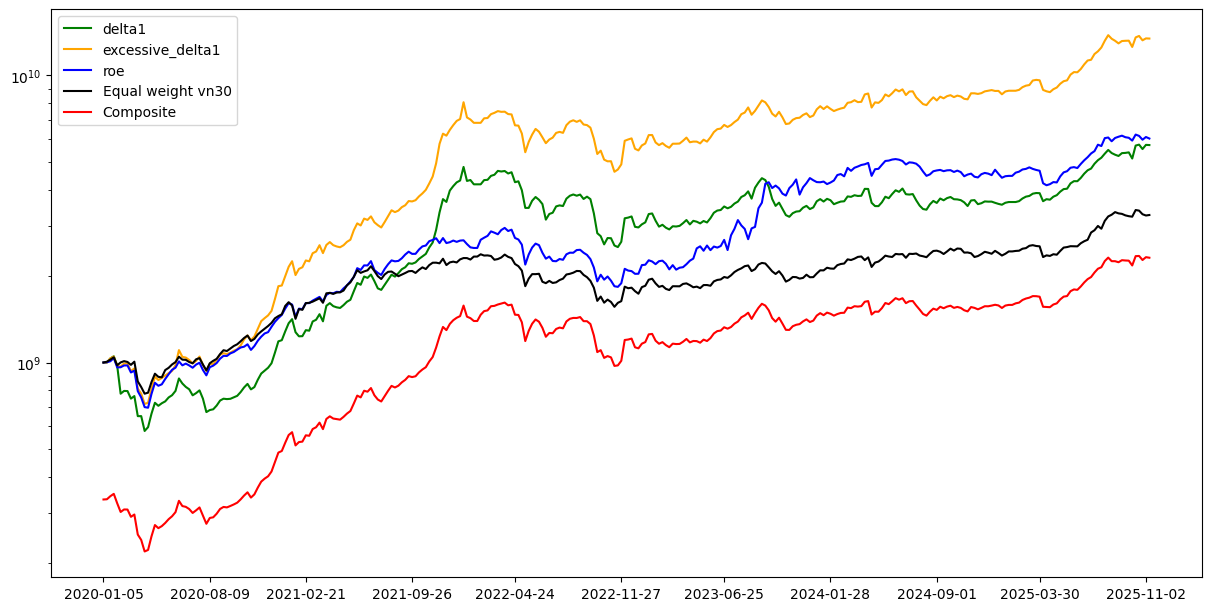

In [24]:
backtest_composite = pd.read_csv("backtest/composite_delta1_excessivedelta_roe.csv")
backtest_composite = list(backtest_composite['equity'])

figure(figsize=(12, 6), dpi=160)
fig,ax= plt.subplots(figsize=(12, 6), layout='constrained')
ax.plot(timerange,backtest_delta1,label = "delta1",color="green")
ax.plot(timerange,backtest_excessive_delta1,label = "excessive_delta1",color="orange")
ax.plot(timerange,backtest_roe,label = "roe",color="blue")
ax.plot(timerange,backtest_vn30,label = "Equal weight vn30",color="black")
ax.plot(timerange,backtest_composite,label = "Composite",color="red")

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.set_yscale('log') 
ax.legend()
#plt.gcf().autofmt_xdate()
plt.show()

((capital*weight)//close *close ) * delta = new capital



( capital n) = capitaln-1 + chgn*volume_bought  

cap0 = (weight0*cap0 // close0)*close0 

cap1 =  (  weight1*  ( cap0 + chg0*volume0 ) //close1 ) *close1

capN = (weightN * ( capN-1 + (closeN - closeN-1)*Volume_boughtN-1) //closeN) * closeN